In [1]:
import pandas as pd
d = pd.read_csv('../data/clean_house_data.csv')
d.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Updated numeric features
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
X = d[numeric_features]
y = d['Price']

X_encoded = pd.get_dummies(d[['Location', 'Condition', 'Garage']], drop_first=True)
X = pd.concat([d[numeric_features], X_encoded], axis=1)


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate the model
model_score = model.score(X_test_scaled, y_test)
mae = mean_absolute_error(y_test, model.predict(X_test_scaled))
mse = mean_squared_error(y_test, model.predict(X_test_scaled))
r2 = r2_score(y_test, model.predict(X_test_scaled))

print("Model Score (R²):", model_score)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)



Model Score (R²): 0.010167793921919022
Mean Absolute Error (MAE): 233363.90236567616
Mean Squared Error (MSE): 72666297123.55373
R² Score: 0.010167793921919022


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use numeric and categorical features together
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = pd.get_dummies(d[['Location', 'Condition', 'Garage']], drop_first=True)
X = pd.concat([d[numeric_features], categorical_features], axis=1)
y = d['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Random Forest Model Score (R²):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)


Random Forest Model Score (R²): -0.04110039608170668
Mean Absolute Error (MAE): 238223.18197863532
Mean Squared Error (MSE): 76430035568.22543


In [10]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)


Area                 0.347854
YearBuilt            0.263888
Bedrooms             0.084252
Bathrooms            0.067655
Floors               0.054971
Condition_Fair       0.031507
Garage_Yes           0.028120
Location_Rural       0.026656
Location_Urban       0.025012
Location_Suburban    0.024670
Condition_Poor       0.023082
Condition_Good       0.022333
dtype: float64


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [12]:

# Use numeric and categorical features together
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = pd.get_dummies(d[['Location', 'Condition', 'Garage']], drop_first=True)
X = pd.concat([d[numeric_features], categorical_features], axis=1)
y = d['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=4, min_samples_split=2, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Random Forest Model Score (R²):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

Random Forest Model Score (R²): -0.04689790151115192
Mean Absolute Error (MAE): 238578.54640074674
Mean Squared Error (MSE): 76855646342.98563


In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use numeric and categorical features together
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = pd.get_dummies(d[['Location', 'Condition', 'Garage']], drop_first=True)
X = pd.concat([d[numeric_features], categorical_features], axis=1)
y = d['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("XGBoost Model Score (R²):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)


XGBoost Model Score (R²): -0.14436721801757812
Mean Absolute Error (MAE): 248433.359375
Mean Squared Error (MSE): 84011130880.0


In [18]:
import pandas as pd

d = pd.read_csv('../data/clean_house_data.csv')
d.head()

# Step 1: Interaction Features
d['TotalRooms'] = d['Bedrooms'] + d['Bathrooms']  # Total number of rooms
d['AreaPerFloor'] = d['Area'] / d['Floors']  # Area divided by number of floors

# Step 2: Temporal Features
d['Age'] = 2025 - d['YearBuilt']  # Age of the house
d['DecadeBuilt'] = (d['YearBuilt'] // 10) * 10  # Decade the house was built

# Step 3: Categorical Feature Encoding
# One-hot encode categorical variables (drop_first=True avoids dummy variable trap)
d = pd.get_dummies(d, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# Step 4: Price per Square Foot
d['PricePerSqft'] = d['Price'] / d['Area']  # Create price per square foot feature

# Check the updated dataset
d.head()




,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,TotalRooms,AreaPerFloor,Age,DecadeBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes,PricePerSqft
0,1,1360,5,4,3,1970,149919,9,453.333333,55,1970,False,False,False,False,False,False,False,110.234559
1,2,4272,5,4,3,1958,424998,9,1424.000000,67,1950,False,False,False,False,False,False,False,99.484551
2,3,3592,2,2,3,1938,266746,4,1197.333333,87,1930,False,False,False,False,True,False,False,74.261136
3,4,966,4,2,2,1902,244020,6,483.000000,123,1900,False,True,False,True,False,False,True,252.608696
4,5,4926,1,4,2,1975,636056,5,2463.000000,50,1970,False,False,False,True,False,False,True,129.122209


In [19]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Updated numeric features
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 
                    'TotalRooms', 'AreaPerFloor', 'Age', 'PricePerSqft']

# Including new categorical one-hot encoded features
categorical_features = [col for col in d.columns if col.startswith(('Location_', 'Condition_', 'Garage_'))]
engineered_features = numeric_features + categorical_features

# Prepare features (X) and target (y)
X = d[engineered_features]
y = d['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Display evaluation metrics
print("XGBoost Model Score (R²):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)


XGBoost Model Score (R²): 0.995772123336792
Mean Absolute Error (MAE): 12836.6884765625
Mean Squared Error (MSE): 310378848.0


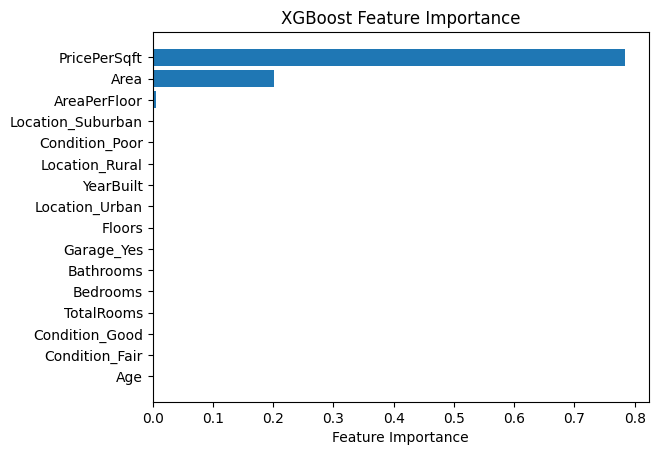

In [20]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns
sorted_idx = importance.argsort()

plt.barh(feature_names[sorted_idx], importance[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()
